# Car Classification
### Dataset: https://www.kaggle.com/datasets/eduardo4jesus/stanford-cars-dataset

#### Library Imports

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_theme(style="white")

##### Load Data

In [2]:
base = "../data/carclassificationdataset1/car_devkit/devkit"

#Load class ID and names
meta = loadmat(f"{base}/cars_meta.mat")
class_names = [c[0] for c in meta['class_names'][0]]
print(f"Number of classes: {len(class_names)}")
print(class_names[:5])


Number of classes: 196
[np.str_('AM General Hummer SUV 2000'), np.str_('Acura RL Sedan 2012'), np.str_('Acura TL Sedan 2012'), np.str_('Acura TL Type-S 2008'), np.str_('Acura TSX Sedan 2012')]


In [3]:
#Annotation Inspection
train_annos = loadmat(f"{base}/cars_train_annos.mat")
print(train_annos['annotations'][0][0])

(array([[39]], dtype=uint8), array([[116]], dtype=uint8), array([[569]], dtype=uint16), array([[375]], dtype=uint16), array([[14]], dtype=uint8), array(['00001.jpg'], dtype='<U9'))


In [4]:
data = []
for anno in train_annos['annotations'][0]:
    data.append({
        'filename': anno[5][0],
        'x1': anno[0][0][0],
        'y1': anno[1][0][0],
        'x2': anno[2][0][0],
        'y2': anno[3][0][0],
        'class_id': anno[4][0][0],
    })

df_train = pd.DataFrame(data)
df_train.head()

,filename,x1,y1,x2,y2,class_id
0,00001.jpg,39,116,569,375,14
1,00002.jpg,36,116,868,587,3
2,00003.jpg,85,109,601,381,91
3,00004.jpg,621,393,1484,1096,134
4,00005.jpg,14,36,133,99,106


In [5]:
df_train['class_name'] = df_train['class_id'].apply(lambda cid: class_names[cid - 1])
df_train.head()

,filename,x1,y1,x2,y2,class_id,class_name
0,00001.jpg,39,116,569,375,14,Audi TTS Coupe 2012
1,00002.jpg,36,116,868,587,3,Acura TL Sedan 2012
2,00003.jpg,85,109,601,381,91,Dodge Dakota Club Cab 2007
3,00004.jpg,621,393,1484,1096,134,Hyundai Sonata Hybrid Sedan 2012
4,00005.jpg,14,36,133,99,106,Ford F-450 Super Duty Crew Cab 2012


In [6]:
test_annos = loadmat(f"{base}/cars_test_annos.mat")
print(test_annos['annotations'][0][0])

(array([[30]], dtype=uint8), array([[52]], dtype=uint8), array([[246]], dtype=uint8), array([[147]], dtype=uint8), array(['00001.jpg'], dtype='<U9'))


##### Data Exploration

In [7]:
class_counts = df_train['class_name'].value_counts()
print(class_counts.describe())
print("\nClasses with fewest images:")
print(class_counts.tail(10))
print('\nClasses with the most images:')
print(class_counts.head(10))

count    196.00000
mean      41.55102
std        4.33382
min       24.00000
25%       39.75000
50%       42.00000
75%       44.00000
max       68.00000
Name: count, dtype: float64

Classes with fewest images:
class_name
FIAT 500 Convertible 2012                              34
Infiniti QX56 SUV 2011                                 33
Bugatti Veyron 16.4 Convertible 2009                   33
Aston Martin Virage Convertible 2012                   33
Acura RL Sedan 2012                                    32
Rolls-Royce Phantom Drophead Coupe Convertible 2012    31
Chevrolet Express Cargo Van 2007                       30
Maybach Landaulet Convertible 2012                     29
FIAT 500 Abarth 2012                                   28
Hyundai Accent Sedan 2012                              24
Name: count, dtype: int64

Classes with the most images:
class_name
GMC Savana Van 2012                         68
Chrysler 300 SRT-8 2010                     49
Mitsubishi Lancer Sedan 2012          

In [8]:
sizes = []
for fname in df_train['filename'].sample(500, random_state=42):
    img_path = f"../data/carclassificationdataset1/cars_train/cars_train/{fname}"
    with Image.open(img_path) as img:
        sizes.append(img.size)

df_sizes = pd.DataFrame(sizes, columns=['width', 'height'])
df_sizes.describe()

,width,height
count,500.000000,500.000000
mean,717.252000,494.462000
std,530.041111,376.071659
min,89.000000,66.000000
25%,424.000000,289.750000
50%,623.000000,418.000000
75%,800.000000,540.750000
max,4608.000000,3456.000000


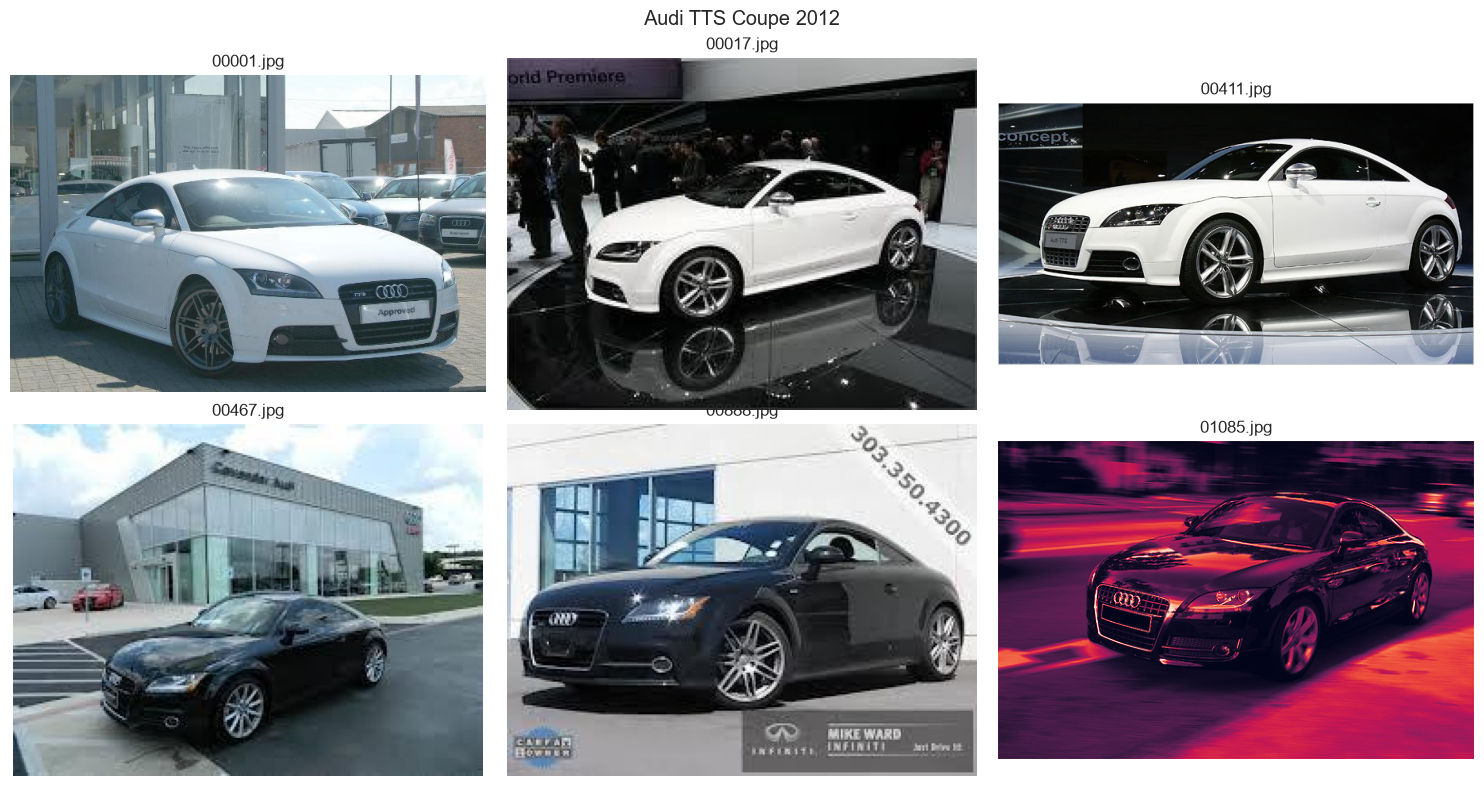

In [9]:
sample_class = df_train['class_name'].iloc[0]
sample_imgs = df_train[df_train['class_name'] == sample_class].head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.flatten(), sample_imgs.iterrows()):
    img_path = f"../data/carclassificationdataset1/cars_train/cars_train/{row['filename']}"
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(row['filename'])
    ax.axis('off')

plt.suptitle(sample_class)
plt.tight_layout()
plt.show()

##### Run Split (70/15/15)

In [10]:
train_df, temp_df = train_test_split(df_train, test_size=0.3, stratify=df_train['class_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class_id'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 5700, Val: 1222, Test: 1222


##### Build Dataset class for resizing and cropping

In [11]:
class CarDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.img_dir}/{row['filename']}").convert("RGB")
        img = img.crop((row['x1'], row['y1'], row['x2'], row['y2']))
        if self.transform:
            img = self.transform(img)
        label = row['class_id'] - 1  # 0-indexed for PyTorch
        return img, label

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [13]:
img_dir = "../data/carclassificationdataset1/cars_train/cars_train"
train_dataset = CarDataset(train_df, img_dir, transform=transform)
val_dataset = CarDataset(val_df, img_dir, transform=transform)
test_dataset = CarDataset(test_df, img_dir, transform=transform)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")
print(labels.min(), labels.max())

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])
tensor(1, dtype=torch.uint8) tensor(189, dtype=torch.uint8)


In [16]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights='IMAGENET1K_V2')
model.fc = nn.Linear(model.fc.in_features, 196)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)

##### Run on GPU rather than CPU with CUDA enabled

In [19]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Ti


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cuda


##### Training Loop
Run on 1 epoch first before commiting to 10

In [25]:
num_epochs = 10

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 2.3076, Train Acc: 0.5411 | Val Loss: 1.5590, Val Acc: 0.6514
Epoch 2/10 | Train Loss: 0.7795, Train Acc: 0.8656 | Val Loss: 0.9885, Val Acc: 0.7480
Epoch 3/10 | Train Loss: 0.2525, Train Acc: 0.9633 | Val Loss: 0.7859, Val Acc: 0.8036
Epoch 4/10 | Train Loss: 0.1101, Train Acc: 0.9904 | Val Loss: 0.7076, Val Acc: 0.8191
Epoch 5/10 | Train Loss: 0.0494, Train Acc: 0.9965 | Val Loss: 0.6671, Val Acc: 0.8208
Epoch 6/10 | Train Loss: 0.0283, Train Acc: 0.9982 | Val Loss: 0.6649, Val Acc: 0.8282
Epoch 7/10 | Train Loss: 0.0195, Train Acc: 0.9984 | Val Loss: 0.6507, Val Acc: 0.8273
Epoch 8/10 | Train Loss: 0.0314, Train Acc: 0.9967 | Val Loss: 0.6712, Val Acc: 0.8216
Epoch 9/10 | Train Loss: 0.0294, Train Acc: 0.9968 | Val Loss: 0.6728, Val Acc: 0.8142
Epoch 10/10 | Train Loss: 0.0223, Train Acc: 0.9974 | Val Loss: 0.6261, Val Acc: 0.8372


In [26]:
model.eval()
test_correct = 0
test_total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 0.7635 | Test Acc: 0.7962


##### Data Augmentation
apply random transformations to training images each epoch

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Val/test not augmented
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [28]:
#Rebuild datasets and dataloaders with new transforms
train_dataset = CarDataset(train_df, img_dir, transform=train_transform)
val_dataset   = CarDataset(val_df, img_dir, transform=eval_transform)
test_dataset  = CarDataset(test_df, img_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
model = models.resnet50(weights='IMAGENET1K_V2')
model.fc = nn.Linear(model.fc.in_features, 196)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # fresh optimizer too

In [35]:
num_epochs = 20
best_val_acc = 0.0

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "../models/classifier/resnet50_stanford_cars_best.pth")
        print(f"  → New best model saved (Val Acc: {val_acc:.4f})")

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

  → New best model saved (Val Acc: 0.8830)
Epoch 1/20 | Train Loss: 0.0469, Train Acc: 0.9926 | Val Loss: 0.4281, Val Acc: 0.8830
Epoch 2/20 | Train Loss: 0.0540, Train Acc: 0.9904 | Val Loss: 0.4739, Val Acc: 0.8674
Epoch 3/20 | Train Loss: 0.0647, Train Acc: 0.9881 | Val Loss: 0.4569, Val Acc: 0.8805
  → New best model saved (Val Acc: 0.8838)
Epoch 4/20 | Train Loss: 0.0383, Train Acc: 0.9935 | Val Loss: 0.4341, Val Acc: 0.8838
  → New best model saved (Val Acc: 0.8993)
Epoch 5/20 | Train Loss: 0.0469, Train Acc: 0.9925 | Val Loss: 0.3945, Val Acc: 0.8993
Epoch 6/20 | Train Loss: 0.0286, Train Acc: 0.9949 | Val Loss: 0.4218, Val Acc: 0.8887
Epoch 7/20 | Train Loss: 0.0386, Train Acc: 0.9939 | Val Loss: 0.4056, Val Acc: 0.8936
Epoch 8/20 | Train Loss: 0.0448, Train Acc: 0.9909 | Val Loss: 0.4501, Val Acc: 0.8822
Epoch 9/20 | Train Loss: 0.0239, Train Acc: 0.9956 | Val Loss: 0.4046, Val Acc: 0.8887
Epoch 10/20 | Train Loss: 0.0172, Train Acc: 0.9963 | Val Loss: 0.4071, Val Acc: 0.8920


In [36]:
model.load_state_dict(torch.load("../models/classifier/resnet50_stanford_cars_best.pth"))
model.eval()

test_correct = 0
test_total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 0.4909 | Test Acc: 0.8789
